Epoch [1/10], Loss: 1.1395
Epoch [2/10], Loss: 1.1106
Epoch [3/10], Loss: 0.9607
Epoch [4/10], Loss: 0.7218
Epoch [5/10], Loss: 2.3570
Epoch [6/10], Loss: 0.7004
Epoch [7/10], Loss: 0.8054
Epoch [8/10], Loss: 0.9036
Epoch [9/10], Loss: 0.9474
Epoch [10/10], Loss: 0.9593
Model saved as 'unet_satellite.pth'


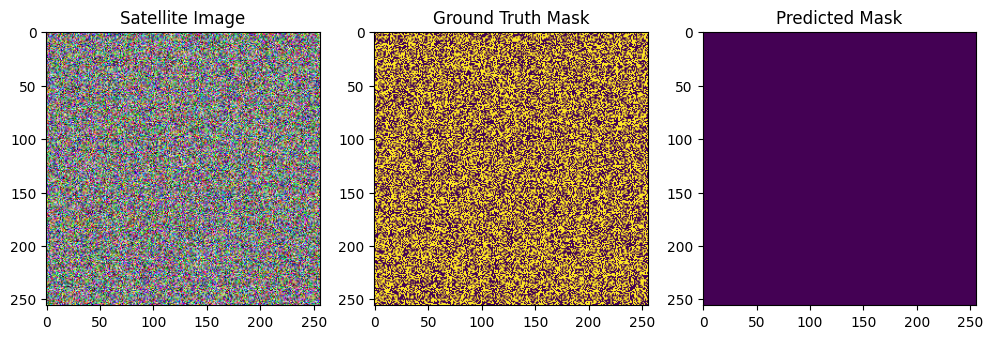

Predicted masks saved in 'predicted_masks'


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
#Dataset Class
class SatelliteDataset (Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(image_dir)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_path= os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        image = transforms.ToTensor() (image)
        mask = torch.tensor(mask, dtype=torch.long)
        return image, mask
#UNet Model
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super (DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)
class UNet(nn.Module):
    def __init__(self, n_classes):
        super(UNet, self).__init__()
        self.dconv_down1 = DoubleConv(3, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up2 = DoubleConv(256+128, 128)
        self.dconv_up1 = DoubleConv (128+64, 64)
        self.conv_last = nn.Conv2d(64, n_classes, 1)
    def forward(self, x):
        # Encoder
        conv1= self.dconv_down1(x)
        x= self.maxpool (conv1)
        conv2= self.dconv_down2(x)
        x= self.maxpool (conv2)
        x= self.dconv_down3(x)
        # Decoder
        # This part needs to be reviewed as the code is incomplete/malformed
        # It seems like there's a missing assignment or a variable name for the upsampled output
        # and then the torch.cat is also standalone without assignment.
        # Assuming the intent was something like:
        x = self.upsample(x) # Fixed assignment
        x = torch.cat([x, conv2], dim=1) # Fixed assignment
        x= self.dconv_up2(x)
        x= self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x= self.dconv_up1(x)
        x = self.conv_last(x)
        return x
# Hyperparameters
batch_size=4
lr = 1e-3 # Corrected typo from '1r 1e-3'
num_epochs = 10
n_classes = 3
#Load Dataset
#Create dummy directories for images and masks to prevent FileNotFoundError
#In a real scenario, you would upload your dataset to these paths or mount Google Drive.
os.makedirs("images/train", exist_ok=True)
os.makedirs("masks/train", exist_ok=True)
#Create dummy image and mask files to avoid empty dataset error
dummy_image = Image.fromarray(np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8))
dummy_mask = Image.fromarray(np.random.randint(0, n_classes - 1, (256, 256), dtype=np.uint8))
dummy_image.save("images/train/dummy_image.png")
dummy_mask.save("masks/train/dummy_image.png")
train_dataset = SatelliteDataset("images/train", "masks/train")
train_loader = DataLoader (train_dataset, batch_size=batch_size, shuffle=True)
#Device, Model, Loss, Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Corrected 'cри'
model = UNet(n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr) # Corrected assignment
#Training Loop#
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0 # Initialized epoch_loss
    for imgs, masks in train_loader:
        imgs = imgs.to(device) # Corrected assignment
        masks = masks.to(device) # Corrected assignment
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}") # Fixed f-string
#Save Model
torch.save(model.state_dict(), "unet_satellite.pth")
print("Model saved as 'unet_satellite.pth'") # Fixed quotes
#Visualize Predictions
# Removed 'ge.png' as it's not a valid Python statement
model.eval()
sample_img, sample_mask = train_dataset[0] # Corrected assignment
with torch.no_grad():
    pred = model(sample_img.unsqueeze(0).to(device))
    pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy() # Corrected 'dim-0'
# Removed 'ge.png' as it's not a valid Python statement
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(sample_img.permute(1,2,0))
plt.title("Satellite Image")
plt.subplot(1,3,2)
plt.imshow(sample_mask)
plt.title("Ground Truth Mask")
plt.subplot(1,3,3)
plt.imshow(pred_mask)
plt.title("Predicted Mask")
plt.show()
#Save Predicted Masks
os.makedirs("predicted_masks", exist_ok=True)
for i in range(len(train_dataset)):
    img, _ = train_dataset[i] # Corrected assignment and ignored mask since not used
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)) # Corrected 'unsqueeze(8)' to 'unsqueeze(0)'
        pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy() # Corrected 'dim=8' to 'dim=0'
    mask_img = Image.fromarray(pred_mask.astype(np.uint8)) # Corrected 'np.uints' to 'np.uint8'
    mask_img.save(f"predicted_masks/mask_{i}.png")
print("Predicted masks saved in 'predicted_masks'")